**Part A - Dataset Creation and Part B- Load and Explore Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pylab
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
import random

In [2]:
np.random.seed(42) #setting seed for reproducibility

rows = 120 # defining no of rows

In [3]:
# Numerical columns (later will include outliers)
num_col1 = np.random.normal(loc=50, scale=10, size=rows)
num_col2 = np.random.normal(loc=100, scale=20, size=rows)

In [4]:
# Inject 5–8 outliers into num_col1
outlier_count = np.random.randint(5, 9)
outlier_indices = np.random.choice(rows, outlier_count, replace=False)
num_col1[outlier_indices] *= 5   # multiply existing values to create extreme outliers

In [5]:
# Categorical columns
category1 = np.random.choice(["Red", "Blue", "Green", "Yellow"], size=rows)
category2 = np.random.choice(["High", "Medium", "Low"], size=rows)

In [6]:
# Date time column
start_date = datetime(2023, 1, 1)
date_col = [
    start_date + timedelta(days=random.randint(0, 365))
    for _ in range(rows)
]

In [7]:
#  Column with 15% missing values
missing_col = np.random.choice(["A", "B", "C", "D"], size=rows).astype(object)

missing_count = int(rows * 0.15)
missing_indices = np.random.choice(rows, missing_count, replace=False)

for idx in missing_indices:
    missing_col[idx] = None

In [8]:
# Create Final DataFrame
df = pd.DataFrame({
    "num_col1": num_col1,
    "num_col2": num_col2,
    "category1": category1,
    "category2": category2,
    "date_col": date_col,
    "missing_col": missing_col
})

In [9]:
df.head()

,num_col1,num_col2,category1,category2,date_col,missing_col
0,54.967142,115.820639,Red,Medium,2023-05-25,A
1,48.617357,81.812251,Green,High,2023-06-14,A
2,56.476885,128.055886,Red,Low,2023-04-06,B
3,65.230299,71.962979,Green,High,2023-11-27,A
4,47.658466,111.737142,Red,Low,2023-05-21,B


In [10]:
df.shape


(120, 6)

In [11]:
df.tail()

,num_col1,num_col2,category1,category2,date_col,missing_col
115,53.015473,112.678380,Red,High,2023-04-07,D
116,49.652882,59.497148,Red,High,2023-09-09,C
117,38.313220,103.729086,Blue,Medium,2023-10-31,None
118,61.428228,86.764271,Yellow,Medium,2023-09-11,A
119,57.519330,117.048667,Blue,Low,2023-01-29,None


In [12]:
df.describe()

,num_col1,num_col2,date_col
count,120.000000,120.000000,120
mean,61.384679,101.487285,2023-06-19 22:48:00
min,23.802549,59.497148,2023-01-04 00:00:00
25%,44.788573,84.829831,2023-03-29 06:00:00
50%,50.326718,103.710882,2023-06-13 12:00:00
75%,57.558085,113.246293,2023-09-09 12:00:00
max,286.923329,177.054630,2024-01-01 00:00:00
std,46.687551,20.246103,NaN


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   num_col1     120 non-null    float64       
 1   num_col2     120 non-null    float64       
 2   category1    120 non-null    object        
 3   category2    120 non-null    object        
 4   date_col     120 non-null    datetime64[ns]
 5   missing_col  102 non-null    object        
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 5.8+ KB


**Part C - Data Cleaning**

In [14]:
# filling missing values
df["num_col1"].fillna(df["num_col1"].mean(), inplace=True)

df["missing_col"].fillna(df["missing_col"].mode()[0], inplace=True)

In [15]:
# Outlier detection using IQR method
Q1 = df["num_col1"].quantile(0.25)
Q3 = df["num_col1"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["is_outlier_IQR"] = (df["num_col1"] < lower_bound) | (df["num_col1"] > upper_bound)

In [16]:
z_scores = (df["num_col1"] - df["num_col1"].mean()) / df["num_col1"].std()
df["is_outlier_Z"] = np.abs(z_scores) > 3

In [17]:
df["category1"] = df["category1"].astype("category")
df["category2"] = df["category2"].astype("category")

# Convert datetime column explicitly
df["date_col"] = pd.to_datetime(df["date_col"])

In [18]:
# Data type correction- categorical, datetime
df["category1"] = df["category1"].astype("category")
df["category2"] = df["category2"].astype("category")

# Convert datetime column explicitly
df["date_col"] = pd.to_datetime(df["date_col"])

In [19]:
# removing rows where num_col2 < 80
filtered_df = df[df["num_col2"] >= 80]

In [20]:
# fix inconsistent data entries
df["category1"] = df["category1"].str.lower().str.capitalize()

In [21]:
filtered_df.head()

,num_col1,num_col2,category1,category2,date_col,missing_col,is_outlier_IQR,is_outlier_Z
0,54.967142,115.820639,Red,Medium,2023-05-25,A,False,False
1,48.617357,81.812251,Green,High,2023-06-14,A,False,False
2,56.476885,128.055886,Red,Low,2023-04-06,B,False,False
4,47.658466,111.737142,Red,Low,2023-05-21,B,False,False
5,238.293152,143.809113,Blue,High,2023-11-12,A,True,True


**PART D- Data Manipulation**

In [22]:
# Using loc: modify a specific row and column by label
df.loc[0, "category1"] = "Red_fixed"

# Using iloc: modify row 5, column 1
df.iloc[5, 1] = df.iloc[5, 1] + 10  # increase num_col2 by 10

In [23]:
df["num_ratio"] = df["num_col1"] / df["num_col2"] # creating a new computed column

In [24]:
group_stats = df.groupby("category1").agg(
    mean_num1=("num_col1", "mean"),
    count_entries=("num_col1", "count"),
    min_num2=("num_col2", "min"),
    max_num2=("num_col2", "max")
)

In [25]:
df_multi = df.set_index(["category1", "category2"])    # HIERARCHICAL INDEXING (MULTI-LEVEL INDEX)
example_multi_row = df_multi.loc[("Red", "High")]     #This is how you navigate the new hierarchy. Since you have two levels of index, you must provide a tuple (Level 1, Level 2) to point to a specific location.


In [26]:
print(example_multi_row)

                      num_col1    num_col2   date_col missing_col  \
category1 category2                                                 
Red       High       57.674347   88.674045 2023-08-20           A   
          High       45.342702  101.371259 2023-06-17           A   
          High       30.867198  109.471849 2023-05-01           D   
          High       35.876963   75.382714 2023-06-13           C   
          High       64.656488  104.549199 2023-03-13           B   
          High       36.718140   76.173930 2023-08-20           D   
          High       46.988963   83.586354 2023-11-19           A   
          High       59.755451  154.403383 2023-10-19           C   
          High       53.613956   91.069701 2023-02-20           B   
          High       44.817298  121.076041 2023-11-07           A   
          High       52.961203   84.543496 2023-03-30           D   
          High       52.610553   95.263628 2023-08-15           C   
          High       53.015473  11

In [27]:
# merge with  a second small dataframe
lookup = pd.DataFrame({ #Create small lookup table
    "category1": ["Red", "Blue", "Green"],
    "group_code": [101, 102, 103]
})
merged_df = df.merge(lookup, on="category1", how="left")

In [28]:
merged_df.head()

,num_col1,num_col2,category1,category2,date_col,missing_col,is_outlier_IQR,is_outlier_Z,num_ratio,group_code
0,54.967142,115.820639,Red_fixed,Medium,2023-05-25,A,False,False,0.474588,NaN
1,48.617357,81.812251,Green,High,2023-06-14,A,False,False,0.594255,103.0
2,56.476885,128.055886,Red,Low,2023-04-06,B,False,False,0.441033,101.0
3,65.230299,71.962979,Green,High,2023-11-27,A,False,False,0.906442,103.0
4,47.658466,111.737142,Red,Low,2023-05-21,B,False,False,0.426523,101.0


**PART E - Statistical Analysis**

In [29]:
# 1. Computing mean, median, mode, variance, standard deviation
mean_val = df["num_col1"].mean()
median_val = df["num_col1"].median()
mode_val = df["num_col1"].mode()[0]
var_val = df["num_col1"].var()
std_val = df["num_col1"].std()

In [30]:
print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)
print("Variance:", var_val)
print("Std Dev:", std_val)

Mean: 61.38467867235157
Median: 50.32671833291744
Mode: 23.802548959102555
Variance: 2179.727395126778
Std Dev: 46.68755075099547


In [31]:
# CORRELATION MATRIX
corr_matrix = df[["num_col1", "num_col2"]].corr(method="pearson")
print("\n=== CORRELATION MATRIX ===")
print(corr_matrix)

if abs(corr_matrix.loc["num_col1", "num_col2"]) > 0.5:
    comment = "Strong correlation detected."
else:
    comment = "Correlation is weak."


=== CORRELATION MATRIX ===
          num_col1  num_col2
num_col1  1.000000 -0.003003
num_col2 -0.003003  1.000000


In [32]:
print(comment)

Correlation is weak.


In [33]:
# SHAPIRO-WILK NORMALITY TEST
shapiro_stat, shapiro_p = stats.shapiro(df["num_col1"])
print("SHAPIRO-WILK TEST (num_col1):")
print("Statistic:", shapiro_stat)
print("p-value:", shapiro_p)

SHAPIRO-WILK TEST (num_col1):
Statistic: 0.4603444226211887
p-value: 4.400805929213095e-19


In [34]:
# ONE-SAMPLE T-TEST (H0: µ = 50)
t_stat, t_p = stats.ttest_1samp(df["num_col1"],50)
print("ONE-SAMPLE T-TEST (num_col1):")
print("t-statistic:", t_stat)
print("p-value:", t_p)


ONE-SAMPLE T-TEST (num_col1):
t-statistic: 2.6712240066103554
p-value: 0.008615804235376596


In [35]:
# ONE-WAY ANOVA (category1 vs num_col2)
groups = [df[df["category1"] == cat]["num_col2"] for cat in df["category1"].unique()]
anova_stat, anova_p = stats.f_oneway(*groups)

print("ONE-WAY ANOVA (category1 vs num_col2)")
print("F-statistic:", anova_stat)
print("p-value:", anova_p)

ONE-WAY ANOVA (category1 vs num_col2)
F-statistic: 0.13460226285224886
p-value: 0.9693060713877013


In [36]:
top_5 = df["category1"].value_counts().head(5) # Find top 5 most frequent values (value_counts)

top_5

,count
category1,
Red,36
Green,32
Blue,27
Yellow,24
Red_fixed,1


In [37]:
# MANN–WHITNEY U TEST
mw_stat, mw_p = stats.mannwhitneyu(df["num_col1"], df["num_col2"])
print("MANN–WHITNEY U TEST:")
print("U-statistic:", mw_stat)
print("p-value:", mw_p)


MANN–WHITNEY U TEST:
U-statistic: 996.0
p-value: 8.734513363923302e-31


In [38]:
 # z-score normalized data for numerical columns

df["num1_zscore"] = (df["num_col1"] - df["num_col1"].mean()) / df["num_col1"].std()
df["num2_zscore"] = (df["num_col2"] - df["num_col2"].mean()) / df["num_col2"].std()

print("Z-SCORE NORMALIZED (HEAD):")
df[["num1_zscore", "num2_zscore"]].head()

Z-SCORE NORMALIZED (HEAD):


,num1_zscore,num2_zscore
0,-0.137457,0.697116
1,-0.273463,-0.966586
2,-0.105120,1.295668
3,0.082369,-1.448415
4,-0.294002,0.497350


In [39]:
Q1 = df["num_col1"].quantile(0.25)
Q3 = df["num_col1"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Lower bound:", lower)
print("Upper bound:", upper)

Lower bound: 25.634305281775482
Upper bound: 76.71235213978764


In [40]:
# CHI-SQUARE TEST (category1 vs category2)
cont_table = pd.crosstab(df["category1"], df["category2"])
chi_stat, chi_p, dof, exp = stats.chi2_contingency(cont_table)
print("CHI-SQUARE TEST (category1 vs category2):")
print("Chi-square statistic:", chi_stat)
print("p-value:", chi_p)

CHI-SQUARE TEST (category1 vs category2):
Chi-square statistic: 13.30130003741115
p-value: 0.10189475170681891


In [41]:
# PEARSON + SPEARMAN CORRELATION
pearson_corr = df["num_col1"].corr(df["num_col2"], method="pearson")
spearman_corr = df["num_col1"].corr(df["num_col2"], method="spearman")
print("Pearson:", pearson_corr)
print("Spearman:", spearman_corr)

Pearson: -0.0030032305619113763
Spearman: 0.05312868949232585


**PART F - Create Visualization plot relevant to your analysis**

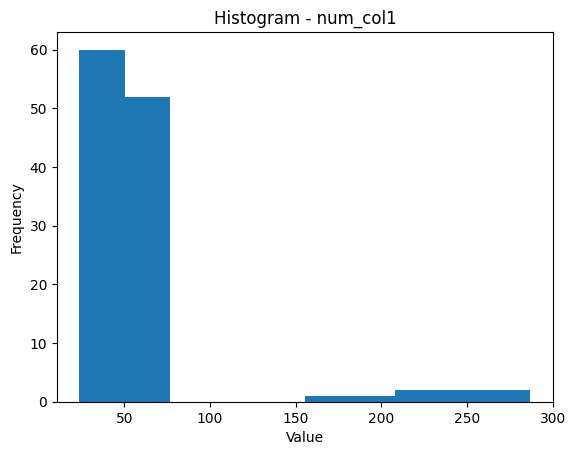

In [44]:
plt.figure()
plt.hist(df["num_col1"])
plt.title("Histogram - num_col1")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

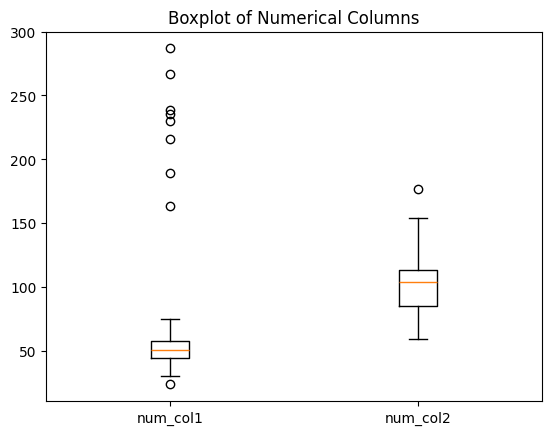

In [45]:
plt.figure()
plt.boxplot([df["num_col1"], df["num_col2"]], labels=["num_col1", "num_col2"])
plt.title("Boxplot of Numerical Columns")
plt.show()

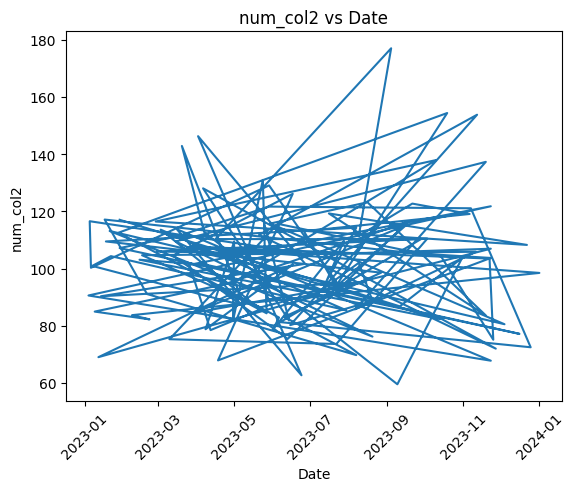

In [46]:
plt.figure()
plt.plot(df["date_col"], df["num_col2"])
plt.title("num_col2 vs Date")
plt.xlabel("Date")
plt.ylabel("num_col2")
plt.xticks(rotation=45)
plt.show()

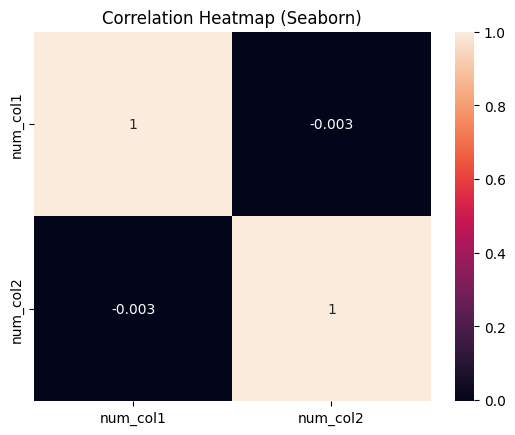

In [48]:
plt.figure()
sns.heatmap(df[["num_col1", "num_col2"]].corr(), annot=True)
plt.title("Correlation Heatmap (Seaborn)")
plt.show()

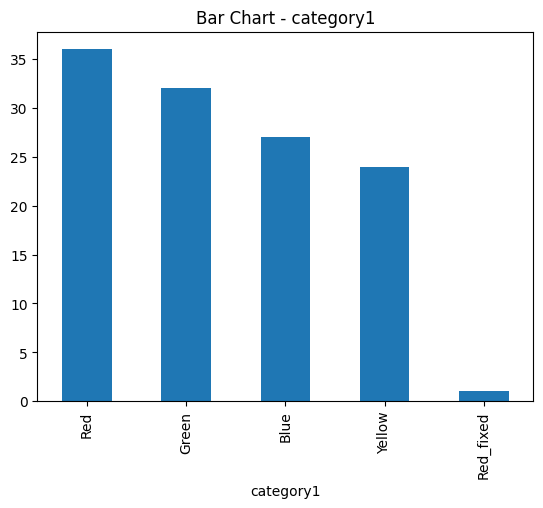

In [49]:
plt.figure()
df["category1"].value_counts().plot(kind="bar")
plt.title("Bar Chart - category1")
plt.show()

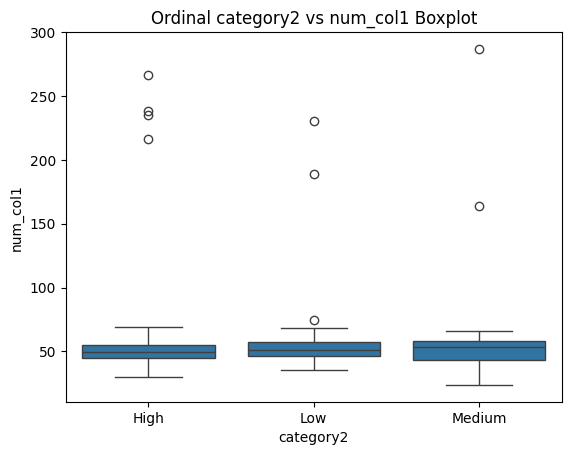

In [50]:
plt.figure()
sns.boxplot(x=df["category2"], y=df["num_col1"])
plt.title("Ordinal category2 vs num_col1 Boxplot")
plt.show()

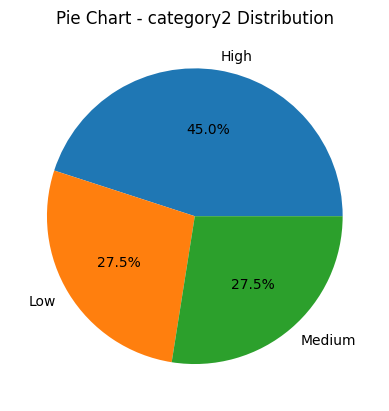

In [51]:
plt.figure()
df["category2"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Pie Chart - category2 Distribution")
plt.ylabel("")
plt.show()

<Figure size 640x480 with 0 Axes>

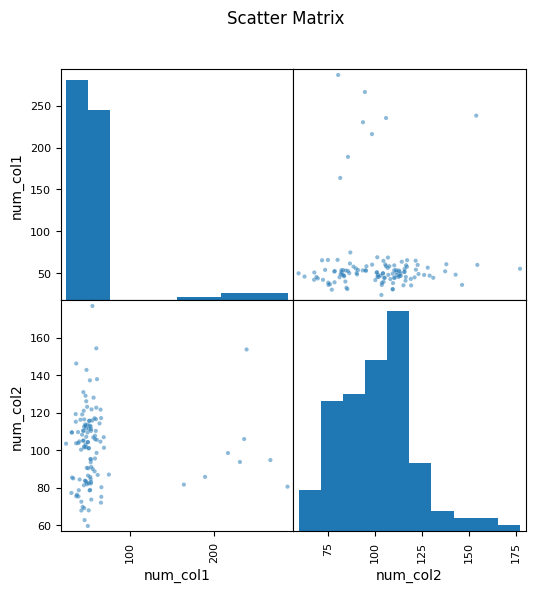

In [55]:
from pandas.plotting import scatter_matrix
plt.figure()
scatter_matrix(df[["num_col1", "num_col2"]], figsize=(6, 6))
plt.suptitle("Scatter Matrix");
plt.show();

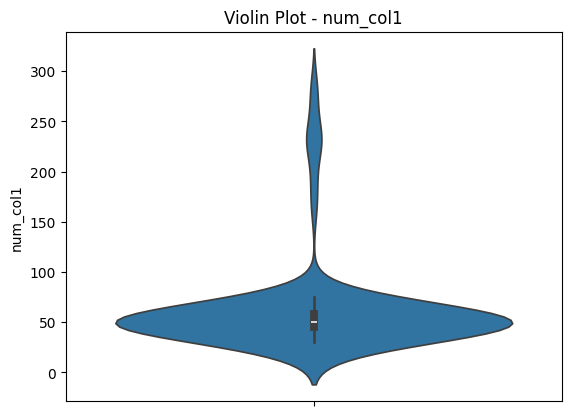

In [56]:
plt.figure()
sns.violinplot(y=df["num_col1"])
plt.title("Violin Plot - num_col1")
plt.show()

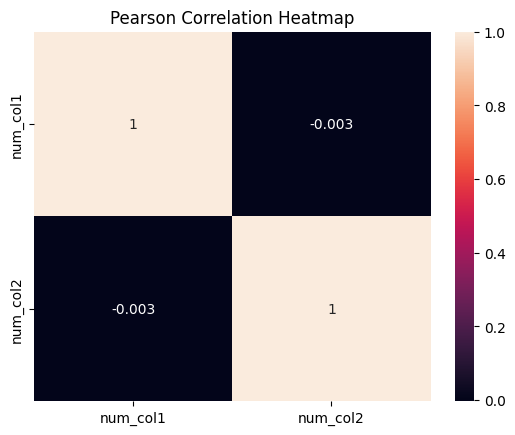

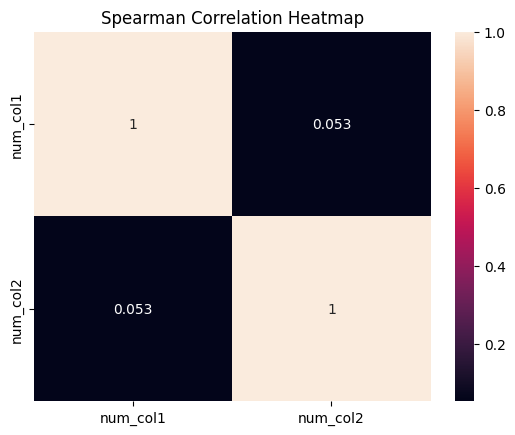

In [58]:
pearson_corr = df[["num_col1", "num_col2"]].corr(method="pearson")
spearman_corr = df[["num_col1", "num_col2"]].corr(method="spearman")

plt.figure()
sns.heatmap(pearson_corr, annot=True)
plt.title("Pearson Correlation Heatmap")
plt.show()

plt.figure()
sns.heatmap(spearman_corr, annot=True)
plt.title("Spearman Correlation Heatmap")
plt.show()